<a href="https://colab.research.google.com/github/u8101081741-source/MISSP/blob/MIS/lab_auto_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Production scheduling -- the job shop problem

## Problem Description
- We have a number of jobs: Job 0, Job 1, Job 2, ...
- We have a number of machines: Machine 0, Machine 1, Machine 2, ...
- Each job must be processed on each machine in a specific order.
- for example: Job 0 must be processed on Machine 0, then on Machine 1, then on Machine 2.
- No machine can process more than one job at a time.
- We assume unlimited buffers between machines, so jobs can immediately move to the next machine if it's available.
- **Objective**: Minimize the total completion time (makespan), C_max.

the effect of the job shop problem is a schedule, frequentely presented as a Gantt chart.

# ![Job shop problem example](https://www.researchgate.net/publication/370490241/figure/fig1/AS:11431281155279843@1683131798236/Job-sequence-on-machines-for-a-job-shop-problem-with-3-machines-and-2-jobs.png)

The problem is NP-hard, the more jobs and machines, the harder it is to solve.



## Mini Problem Example

### Scenario Setup
- **Machines**: 0 and 1
- **Jobs**: 0 and 1
- Each job has two operations, one on each machine, but in different orders

### Job 0
- **Operation 1**: Machine 0 → Processing time = 5
- **Operation 2**: Machine 1 → Processing time = 6
- Thus, Job 0 must go first to Machine 0, then to Machine 1

### Job 1
- **Operation 1**: Machine 1 → Processing time = 4  
- **Operation 2**: Machine 0 → Processing time = 7
- Thus, Job 1 must go first to Machine 1, then to Machine 0

### Objective
Minimize the makespan (C_max)

In [1]:
!pip install pulp

import pulp

# 1) Create the problem
model = pulp.LpProblem("Small_Job_Shop", pulp.LpMinimize)

# 2) Decision variables
# Start times:
# s0_0: Start time of Job 0 on Machine 0
# s0_1: Start time of Job 0 on Machine 1
# s1_0: Start time of Job 1 on Machine 0
# s1_1: Start time of Job 1 on Machine 1
s0_0 = pulp.LpVariable("s0_0", lowBound=0, cat='Continuous')
s0_1 = pulp.LpVariable("s0_1", lowBound=0, cat='Continuous')
s1_0 = pulp.LpVariable("s1_0", lowBound=0, cat='Continuous')
s1_1 = pulp.LpVariable("s1_1", lowBound=0, cat='Continuous')

# Makespan
Cmax = pulp.LpVariable("Cmax", lowBound=0, cat='Continuous')

# 3) Processing times
# Job 0: M0=5, then M1=6
p0_m0 = 8 # processing time of Job 0 on Machine 0
p0_m1 = 3 # processing time of Job 0 on Machine 1

# Job 1: M1=4, then M0=7
p1_m1 = 1 # processing time of Job 1 on Machine 1
p1_m0 = 4 # processing time of Job 1 on Machine 0

# 4) Binary variables for machine usage ordering
# We need these to ensure no overlap on each machine - each machine can process only one job at a time.
# For Machine 0, let y0_01 = 1 if Job 0 finishes before Job 1 starts on M0, else 0.
# For Machine 1, let y1_01 = 1 if Job 0 finishes before Job 1 starts on M1, else 0.
y0_01 = pulp.LpVariable("y0_01", cat='Binary')  # ordering on Machine 0
y1_01 = pulp.LpVariable("y1_01", cat='Binary')  # ordering on Machine 1

# Define a "big M" large enough to cover maximum possible scheduling time
bigM = 9999

# 5) OBJECTIVE: minimize Cmax
model += Cmax, "Minimize_the_makespan"

# 6) CONSTRAINTS

# -- (A) Operation sequence for each job --

# Job 0 must finish on Machine 0 before starting on Machine 1:
model += s0_1 >= s0_0 + p0_m0, "Seq_Job0" # start time of Job 0 on Machine 1 must be greater than or equal to the start time of Job 0 on Machine 0 plus the processing time of Job 0 on Machine 0

# Job 1 must finish on Machine 1 before starting on Machine 0:
model += s1_0 >= s1_1 + p1_m1, "Seq_Job1" # start time of Job 1 on Machine 0 must be greater than or equal to the start time of Job 1 on Machine 1 plus the processing time of Job 1 on Machine 1

# -- (B) No overlap on Machine 0 --
# Machine 0 is used by:
#   - Job 0 (from s0_0 to s0_0 + p0_m0)
#   - Job 1 (from s1_0 to s1_0 + p1_m0)
# Use a big-M approach with binary y0_01:

# If y0_01 = 1, Job0 finishes before Job1 starts on M0:
#     s1_0 >= s0_0 + p0_m0 - bigM*(1 - y0_01)
model += s1_0 >= s0_0 + p0_m0 - bigM*(1 - y0_01), "NoOverlap0a"

# If y0_01 = 0, Job1 finishes before Job0 starts on M0:
#     s0_0 >= s1_0 + p1_m0 - bigM*(y0_01)
model += s0_0 >= s1_0 + p1_m0 - bigM*(y0_01), "NoOverlap0b"

# -- (C) No overlap on Machine 1 --
# Machine 1 is used by:
#   - Job 0 (from s0_1 to s0_1 + p0_m1)
#   - Job 1 (from s1_1 to s1_1 + p1_m1)
# Use a big-M approach with y1_01:

# If y1_01 = 1, Job0 finishes before Job1 starts on M1:
#     s1_1 >= s0_1 + p0_m1 - bigM*(1 - y1_01)
model += s1_1 >= s0_1 + p0_m1 - bigM*(1 - y1_01), "NoOverlap1a"

# If y1_01 = 0, Job1 finishes before Job0 starts on M1:
#     s0_1 >= s1_1 + p1_m1 - bigM*(y1_01)
model += s0_1 >= s1_1 + p1_m1 - bigM*(y1_01), "NoOverlap1b"

# -- (D) Makespan definition --
# Finish time for Job 0 = time it completes on Machine 1 = s0_1 + p0_m1
# Finish time for Job 1 = time it completes on Machine 0 = s1_0 + p1_m0

model += Cmax >= s0_1 + p0_m1, "Makespan_Job0"
model += Cmax >= s1_0 + p1_m0, "Makespan_Job1"

# 7) Solve the model
model.solve(pulp.PULP_CBC_CMD(msg=False))

# 8) Print results
print("Status:", pulp.LpStatus[model.status])
print("Objective (makespan) =", pulp.value(model.objective))

# Decision variable values:
print("--- Start Times ---")
print("s0_0 (Job0 on M0) =", pulp.value(s0_0))
print("s0_1 (Job0 on M1) =", pulp.value(s0_1))
print("s1_0 (Job1 on M0) =", pulp.value(s1_0))
print("s1_1 (Job1 on M1) =", pulp.value(s1_1))

print("--- Binary Orders ---")
print("y0_01 (Machine 0 order) =", pulp.value(y0_01))
print("y1_01 (Machine 1 order) =", pulp.value(y1_01))

Status: Optimal
Objective (makespan) = 12.0
--- Start Times ---
s0_0 (Job0 on M0) = 0.0
s0_1 (Job0 on M1) = 8.0
s1_0 (Job1 on M0) = 8.0
s1_1 (Job1 on M1) = 0.0
--- Binary Orders ---
y0_01 (Machine 0 order) = 1.0
y1_01 (Machine 1 order) = 0.0


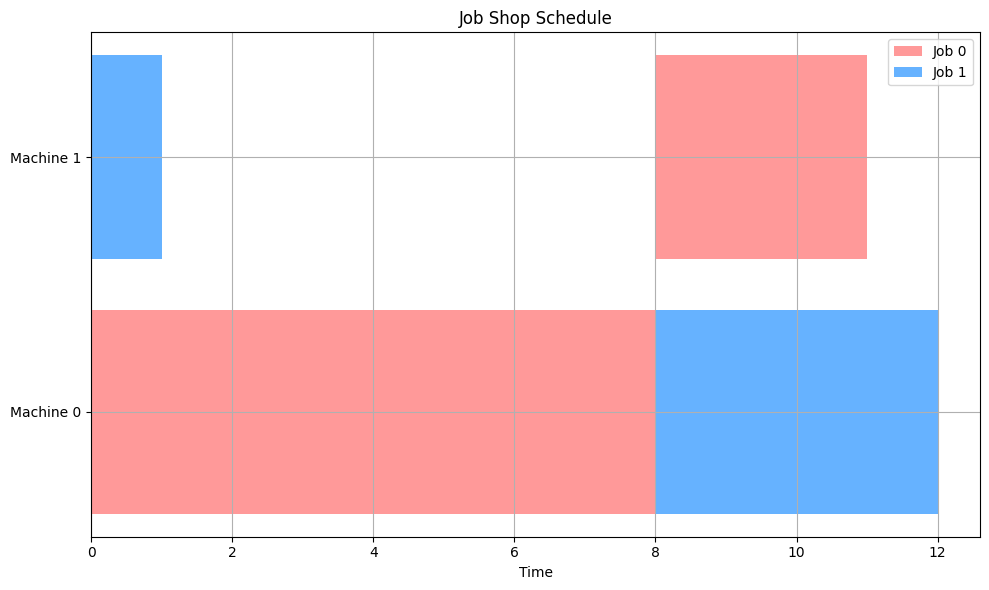

In [2]:
import matplotlib.pyplot as plt

# Create Gantt chart
fig, ax = plt.subplots(figsize=(10, 6))

# Colors for each job
colors = ['#FF9999', '#66B2FF']

# For each machine
for m in range(2):
    # Plot Job 0 on this machine
    if m == 0:
        start = pulp.value(s0_0)
        duration = p0_m0
    else:
        start = pulp.value(s0_1)
        duration = p0_m1
    ax.barh(m, duration, left=start, color=colors[0], label='Job 0' if m==0 else "")

    # Plot Job 1 on this machine
    if m == 0:
        start = pulp.value(s1_0)
        duration = p1_m0
    else:
        start = pulp.value(s1_1)
        duration = p1_m1
    ax.barh(m, duration, left=start, color=colors[1], label='Job 1' if m==0 else "")

# Customize the chart
ax.set_yticks(range(2))
ax.set_yticklabels(['Machine 0', 'Machine 1'])
ax.set_xlabel('Time')
ax.set_title('Job Shop Schedule')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


# Excercise 1

Play with the code above to see how the schedule changes with different processing times.



#More general job shop problem example

## Data Setup
Let's define for each job:
- The machine sequence the job must follow
- The processing time on each machine (in hours)

### Job Specifications:

**Job 0:**
- Machine sequence: Machine 0 → Machine 1 → Machine 2
- Processing times: 5, 6, 4 hours respectively

**Job 1:**
- Machine sequence: Machine 1 → Machine 2 → Machine 0  
- Processing times: 4, 3, 7 hours respectively

**Job 2:**
- Machine sequence: Machine 0 → Machine 2 → Machine 1
- Processing times: 6, 4, 5 hours respectively

We will store this data in two parallel 2D lists:
- `machine_order`: Contains the sequence of machines for each job
- `processing_time`: Contains the corresponding processing times



In [3]:
#!pip install pulp

import pulp

# -------------------------
# 1) PROBLEM PARAMETERS
# -------------------------
num_jobs = 3
num_machines = 3

# machine_order[job] = list of machines in the order they must be processed
# Example: Job 0 -> Machine 0 -> Machine 1 -> Machine 2
machine_order = [
    [0, 1, 2],  # Job 0
    [2, 1, 0],  # Job 1
    [1, 2, 0]   # Job 2
]

# processing_time[job] = list of processing times for each operation in the sequence
# For Job 0: 5 hours on Machine 0, 6 hours on Machine 1, 4 hours on Machine 2
processing_time = [
    [4, 4, 4],  # Job 0
    [1, 6, 5],  # Job 1
    [6, 2, 1]   # Job 2
]

# -------------------------
# 2) DECISION VARIABLES
# -------------------------
# We'll create a variable start_time[m, j] = the start time of Job j on Machine m.
# Because each job visits each machine exactly once (in a known order), we can define variables for each (m, j).
# Alternatively, we might define them only in operation order; for simplicity, we'll define them for (m, j).
start_time = pulp.LpVariable.dicts(
    "start_time",
    [(m, j) for m in range(num_machines) for j in range(num_jobs)],
    lowBound=0,
    cat='Continuous'
)

# We'll create a variable Cmax to represent the makespan (the maximum finishing time).
Cmax = pulp.LpVariable('Cmax', lowBound=0, cat='Continuous')

# -------------------------
# 3) MODEL
# -------------------------
model = pulp.LpProblem("Job_Shop_Scheduling", pulp.LpMinimize)

# Objective: Minimize the makespan
model += Cmax, "Minimize_makespan"

# -------------------------
# 4) CONSTRAINTS
# -------------------------

# (A) **Operation sequence** constraints:
#     For each job j, each operation must start after the previous one finishes.

for j in range(num_jobs):
    for op in range(num_machines - 1):
        current_machine = machine_order[j][op]
        next_machine = machine_order[j][op + 1]

        current_op_time = processing_time[j][op]

        # The start of the next operation must be >= (start of current operation + processing time).
        model += start_time[next_machine, j] >= (
            start_time[current_machine, j] + current_op_time
        ), f"SequenceConstraint_Job{j}_Op{op}"

# (B) **No overlap on the same machine**:
#     If two jobs j1 and j2 require the same machine m, only one can run at a time.
#     We'll use the "big-M" approach with binary variables to enforce non-overlapping intervals.

# Big M can be a large enough number. For a small example, let's pick something > sum of all times.
bigM = 9999

# Create binary variables that indicate ordering between job pairs on each machine.
# y[m, j1, j2] = 1 means job j1 finishes before job j2 starts (on machine m).
y = pulp.LpVariable.dicts(
    "y",
    [(m, j1, j2) for m in range(num_machines) for j1 in range(num_jobs) for j2 in range(num_jobs) if j1 != j2],
    cat='Binary'
)

for m in range(num_machines):
    # Retrieve jobs that run on machine m, but we actually know each job runs on m exactly once in some order
    # We just loop over all pairs j1, j2.
    for j1 in range(num_jobs):
        for j2 in range(num_jobs):
            if j1 != j2:
                # processing time of job j1 on machine m
                # We need to figure out which operation index job j1 uses machine m
                op_j1 = machine_order[j1].index(m)  # index of machine m in job j1's sequence
                proc_j1 = processing_time[j1][op_j1]

                op_j2 = machine_order[j2].index(m)
                proc_j2 = processing_time[j2][op_j2]

                # Non-overlap constraints:
                # start_time[m, j2] >= start_time[m, j1] + proc_j1 - bigM*(1 - y[m, j1, j2])
                model += start_time[m, j2] >= start_time[m, j1] + proc_j1 - bigM * (1 - y[m, j1, j2])

                # Similarly:
                # start_time[m, j1] >= start_time[m, j2] + proc_j2 - bigM*(y[m, j1, j2])
                model += start_time[m, j1] >= start_time[m, j2] + proc_j2 - bigM * (y[m, j1, j2])

# (C) **Makespan definition**:
#     For each job j, the finishing time on its last machine must be <= Cmax.
for j in range(num_jobs):
    # last machine index for job j (the job visits machines in a known order)
    last_machine = machine_order[j][-1]
    # last operation index (which is num_machines - 1)
    last_op_idx = num_machines - 1
    finish_time_j = start_time[last_machine, j] + processing_time[j][last_op_idx]

    model += Cmax >= finish_time_j, f"CmaxConstraint_Job{j}"

# -------------------------
# 5) SOLVE
# -------------------------
model.solve(pulp.PULP_CBC_CMD(msg=False))

print("Solution Status:", pulp.LpStatus[model.status])
print("Objective (makespan) =", pulp.value(model.objective))

# Print the start times
for (m, j) in start_time:
    print(f"Start time of Job {j} on Machine {m} = {pulp.value(start_time[m, j])}")


Solution Status: Optimal
Objective (makespan) = 20.0
Start time of Job 0 on Machine 0 = 0.0
Start time of Job 1 on Machine 0 = 12.0
Start time of Job 2 on Machine 0 = 11.0
Start time of Job 0 on Machine 1 = 12.0
Start time of Job 1 on Machine 1 = 6.0
Start time of Job 2 on Machine 1 = 0.0
Start time of Job 0 on Machine 2 = 16.0
Start time of Job 1 on Machine 2 = 0.0
Start time of Job 2 on Machine 2 = 6.0


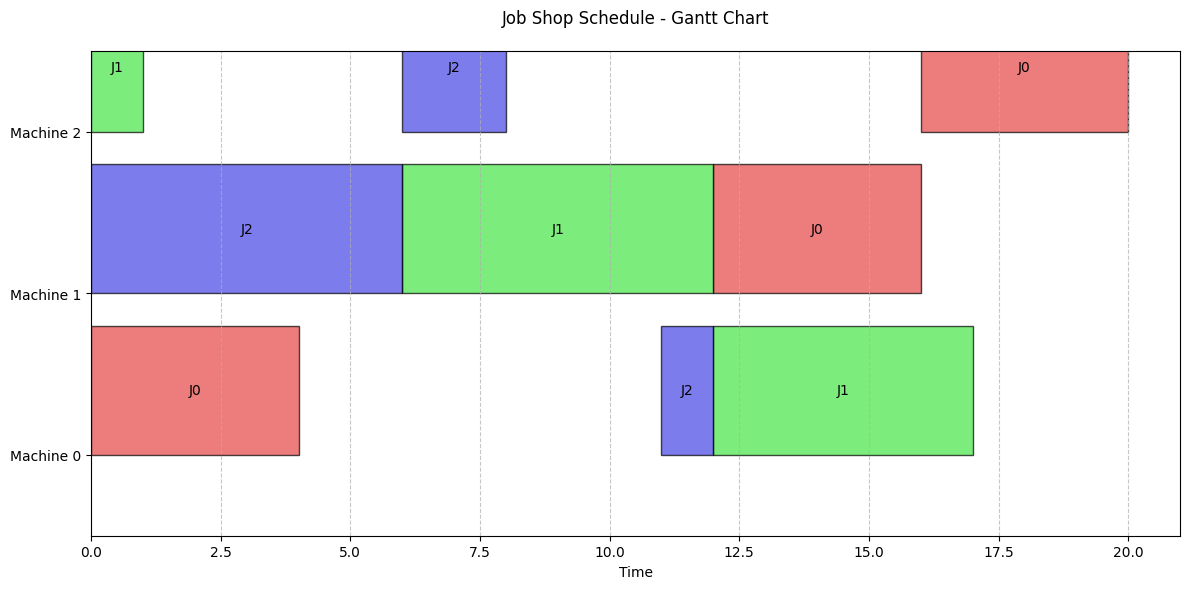

In [4]:
# Create Gantt chart
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import colorsys

# Set up the plot with dynamic sizing based on number of machines
fig_height = max(6, num_machines * 0.5)  # Increase height for many machines
fig, ax = plt.subplots(figsize=(12, fig_height))

# Generate colors dynamically based on number of jobs
def generate_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.7
        value = 0.9
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        colors.append(rgb)
    return colors

colors = generate_colors(num_jobs)

# For each machine and job
for m in range(num_machines):
    for j in range(num_jobs):
        # Get start time and processing time
        start = pulp.value(start_time[m, j])
        op_idx = machine_order[j].index(m)
        duration = processing_time[j][op_idx]

        # Calculate rectangle height based on number of machines
        rect_height = min(0.8, 0.95 - (0.01 * num_machines))

        # Create rectangle for this operation
        rect = patches.Rectangle(
            (start, m),                     # (x,y)
            duration,                       # width
            rect_height,                    # height
            facecolor=colors[j],
            edgecolor='black',
            alpha=0.7
        )

        # Add rectangle to plot
        ax.add_patch(rect)

        # Adjust text size based on number of jobs and machines
        text_size = max(8, min(10, 200/(num_jobs * num_machines)))

        # Add job number text in the middle of rectangle
        ax.text(start + duration/2, m + rect_height/2, f'J{j}',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=text_size)

# Customize the plot
ax.set_ylim(-0.5, num_machines - 0.5)
ax.set_xlim(0, pulp.value(Cmax) * 1.05)  # Add 5% margin

# Adjust tick label size based on number of machines
tick_size = max(8, min(10, 120/num_machines))
ax.set_yticks(range(num_machines))
ax.set_yticklabels([f'Machine {m}' for m in range(num_machines)], fontsize=tick_size)
ax.set_xlabel('Time', fontsize=tick_size)
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.title('Job Shop Schedule - Gantt Chart', pad=20, fontsize=tick_size + 2)
plt.tight_layout()
plt.show()


# Excercise 1b:
Play with the code above, see how the Cmax changes with different processing times, different variations of the problem.
# Excercise 2

Add a machine to the problem. Use %%timeit to see how the solver performance changes.

In [5]:
# Cmax sie zwiekszyl poniewaz wiecej czasu pracuja maszyny, kod dziala git wartosci w macierzy sa ok, do tego co jest na wykresie :)

Solution Status: Optimal
Objective (makespan) = 20.0
Start time of Job 0 on Machine 0 = 0.0
Start time of Job 1 on Machine 0 = 9.0
Start time of Job 2 on Machine 0 = 8.0
Start time of Job 0 on Machine 1 = 9.0
Start time of Job 1 on Machine 1 = 6.0
Start time of Job 2 on Machine 1 = 0.0
Start time of Job 0 on Machine 2 = 14.0
Start time of Job 1 on Machine 2 = 0.0
Start time of Job 2 on Machine 2 = 6.0
Start time of Job 0 on Machine 3 = 18.0
Start time of Job 1 on Machine 3 = 14.0
Start time of Job 2 on Machine 3 = 9.0


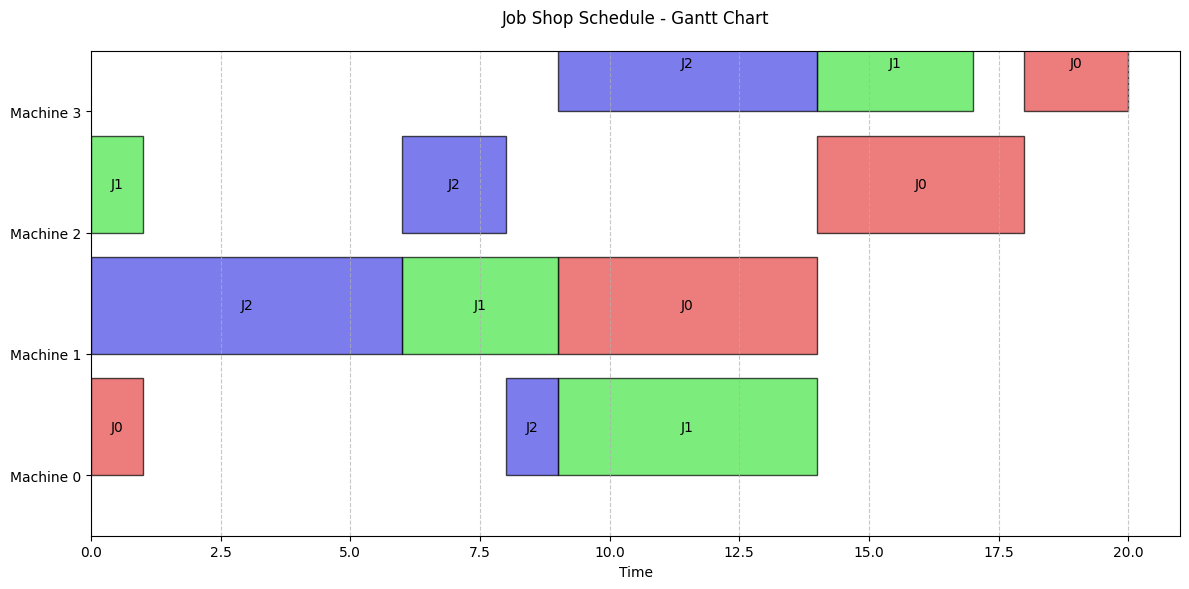

In [6]:
#!pip install pulp

import pulp

# -------------------------
# 1) PROBLEM PARAMETERS
# -------------------------
num_jobs = 3
num_machines = 4 # Increased to 4 machines

# machine_order[job] = list of machines in the order they must be processed
# Example: Job 0 -> Machine 0 -> Machine 1 -> Machine 2 -> Machine 3
machine_order = [
    [0, 1, 2, 3],  # Job 0 - Added Machine 3
    [2, 1, 0, 3],  # Job 1 - Added Machine 3
    [1, 2, 0, 3]   # Job 2 - Added Machine 3
]

# processing_time[job] = list of processing times for each operation in the sequence
# For Job 0: 4 hours on Machine 0, 4 hours on Machine 1, 4 hours on Machine 2, 2 hours on Machine 3
processing_time = [
    [1, 5, 4, 2],  # Job 0 - Added processing time for Machine 3
    [1, 3, 5, 3],  # Job 1 - Added processing time for Machine 3
    [6, 2, 1, 5]   # Job 2 - Added processing time for Machine 3
]

# -------------------------
# 2) DECISION VARIABLES
# -------------------------
# We'll create a variable start_time[m, j] = the start time of Job j on Machine m.
# Because each job visits each machine exactly once (in a known order), we can define variables for each (m, j).
# Alternatively, we might define them only in operation order; for simplicity, we'll define them for (m, j).
start_time = pulp.LpVariable.dicts(
    "start_time",
    [(m, j) for m in range(num_machines) for j in range(num_jobs)],
    lowBound=0,
    cat='Continuous'
)

# We'll create a variable Cmax to represent the makespan (the maximum finishing time).
Cmax = pulp.LpVariable('Cmax', lowBound=0, cat='Continuous')

# -------------------------
# 3) MODEL
# -------------------------
model = pulp.LpProblem("Job_Shop_Scheduling", pulp.LpMinimize)

# Objective: Minimize the makespan
model += Cmax, "Minimize_makespan"

# -------------------------
# 4) CONSTRAINTS
# -------------------------

# (A) **Operation sequence** constraints:
#     For each job j, each operation must start after the previous one finishes.

for j in range(num_jobs):
    # Changed range to num_machines - 1 as num_machines is now 4
    for op in range(num_machines - 1):
        current_machine = machine_order[j][op]
        next_machine = machine_order[j][op + 1]

        current_op_time = processing_time[j][op]

        # The start of the next operation must be >= (start of current operation + processing time).
        model += start_time[next_machine, j] >= (
            start_time[current_machine, j] + current_op_time
        ), f"SequenceConstraint_Job{j}_Op{op}"

# (B) **No overlap on the same machine**:
#     If two jobs j1 and j2 require the same machine m, only one can run at a time.
#     We'll use the "big-M" approach with binary variables to enforce non-overlapping intervals.

# Big M can be a large enough number. For a small example, let's pick something > sum of all times.
bigM = 9999

# Create binary variables that indicate ordering between job pairs on each machine.
# y[m, j1, j2] = 1 means job j1 finishes before job j2 starts (on machine m).
y = pulp.LpVariable.dicts(
    "y",
    [(m, j1, j2) for m in range(num_machines) for j1 in range(num_jobs) for j2 in range(num_jobs) if j1 != j2],
    cat='Binary'
)

for m in range(num_machines): # Changed range to num_machines
    # Retrieve jobs that run on machine m, but we actually know each job runs on m exactly once in some order
    # We just loop over all pairs j1, j2.
    for j1 in range(num_jobs):
        for j2 in range(num_jobs):
            if j1 != j2:
                # processing time of job j1 on machine m
                # We need to figure out which operation index job j1 uses machine m
                op_j1 = machine_order[j1].index(m)  # index of machine m in job j1's sequence
                proc_j1 = processing_time[j1][op_j1]

                op_j2 = machine_order[j2].index(m)
                proc_j2 = processing_time[j2][op_j2]

                # Non-overlap constraints:
                # start_time[m, j2] >= start_time[m, j1] + proc_j1 - bigM*(1 - y[m, j1, j2])
                model += start_time[m, j2] >= start_time[m, j1] + proc_j1 - bigM * (1 - y[m, j1, j2])

                # Similarly:
                # start_time[m, j1] >= start_time[m, j2] + proc_j2 - bigM*(y[m, j1, j2])
                model += start_time[m, j1] >= start_time[m, j2] + proc_j2 - bigM * (y[m, j1, j2])

# (C) **Makespan definition**:
#     For each job j, the finishing time on its last machine must be <= Cmax.
for j in range(num_jobs):
    # last machine index for job j (the job visits machines in a known order)
    last_machine = machine_order[j][-1]
    # last operation index (which is num_machines - 1)
    last_op_idx = num_machines - 1 # Changed to num_machines - 1
    finish_time_j = start_time[last_machine, j] + processing_time[j][last_op_idx]

    model += Cmax >= finish_time_j, f"CmaxConstraint_Job{j}"

# -------------------------
# 5) SOLVE
# -------------------------
model.solve(pulp.PULP_CBC_CMD(msg=False))

print("Solution Status:", pulp.LpStatus[model.status])
print("Objective (makespan) =", pulp.value(model.objective))

# Print the start times
for (m, j) in start_time:
    print(f"Start time of Job {j} on Machine {m} = {pulp.value(start_time[m, j])}")

# Create Gantt chart
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import colorsys

# Set up the plot with dynamic sizing based on number of machines
fig_height = max(6, num_machines * 0.5)  # Increase height for many machines
fig, ax = plt.subplots(figsize=(12, fig_height))

# Generate colors dynamically based on number of jobs
def generate_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.7
        value = 0.9
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        colors.append(rgb)
    return colors

colors = generate_colors(num_jobs)

# For each machine and job
for m in range(num_machines):
    for j in range(num_jobs):
        # Get start time and processing time
        start = pulp.value(start_time[m, j])
        op_idx = machine_order[j].index(m)
        duration = processing_time[j][op_idx]

        # Calculate rectangle height based on number of machines
        rect_height = min(0.8, 0.95 - (0.01 * num_machines))

        # Create rectangle for this operation
        rect = patches.Rectangle(
            (start, m),                     # (x,y)
            duration,                       # width
            rect_height,                    # height
            facecolor=colors[j],
            edgecolor='black',
            alpha=0.7
        )

        # Add rectangle to plot
        ax.add_patch(rect)

        # Adjust text size based on number of jobs and machines
        text_size = max(8, min(10, 200/(num_jobs * num_machines)))

        # Add job number text in the middle of rectangle
        ax.text(start + duration/2, m + rect_height/2, f'J{j}',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=text_size)

# Customize the plot
ax.set_ylim(-0.5, num_machines - 0.5)
ax.set_xlim(0, pulp.value(Cmax) * 1.05)  # Add 5% margin

# Adjust tick label size based on number of machines
tick_size = max(8, min(10, 120/num_machines))
ax.set_yticks(range(num_machines))
ax.set_yticklabels([f'Machine {m}' for m in range(num_machines)], fontsize=tick_size)
ax.set_xlabel('Time', fontsize=tick_size)
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.title('Job Shop Schedule - Gantt Chart', pad=20, fontsize=tick_size + 2)
plt.tight_layout()
plt.show()

# Excercise 3:

Make the problem interactive, add a way to specify the number of jobs and machines interactively

The problem can be very hard for a larger number of jobs and machines. There are some heuristics that can be used to solve it. Some interesting methods are:
- Genetic algorithms
- Simulated annealing
- Tabu search
- Ant colony optimization
- Particle swarm optimization


Enter the number of jobs: 5
Enter the number of machines: 3

Generated Machine Order:
Job 0: [1, 0, 2]
Job 1: [0, 1, 2]
Job 2: [0, 2, 1]
Job 3: [1, 0, 2]
Job 4: [2, 1, 0]

Generated Processing Times:
Job 0: [4, 9, 2]
Job 1: [8, 5, 4]
Job 2: [6, 1, 9]
Job 3: [9, 9, 2]
Job 4: [8, 2, 2]

Solving the model...
Solution Status: Optimal
Objective (makespan) = 34.0

--- Start Times ---
Start time of Job 0 on Machine 0 = 14.0
Start time of Job 1 on Machine 0 = 0.0
Start time of Job 2 on Machine 0 = 8.0
Start time of Job 3 on Machine 0 = 23.0
Start time of Job 4 on Machine 0 = 32.0
Start time of Job 0 on Machine 1 = 9.0
Start time of Job 1 on Machine 1 = 15.0
Start time of Job 2 on Machine 1 = 20.0
Start time of Job 3 on Machine 1 = 0.0
Start time of Job 4 on Machine 1 = 13.0
Start time of Job 0 on Machine 2 = 24.0
Start time of Job 1 on Machine 2 = 20.0
Start time of Job 2 on Machine 2 = 14.0
Start time of Job 3 on Machine 2 = 32.0
Start time of Job 4 on Machine 2 = 0.0


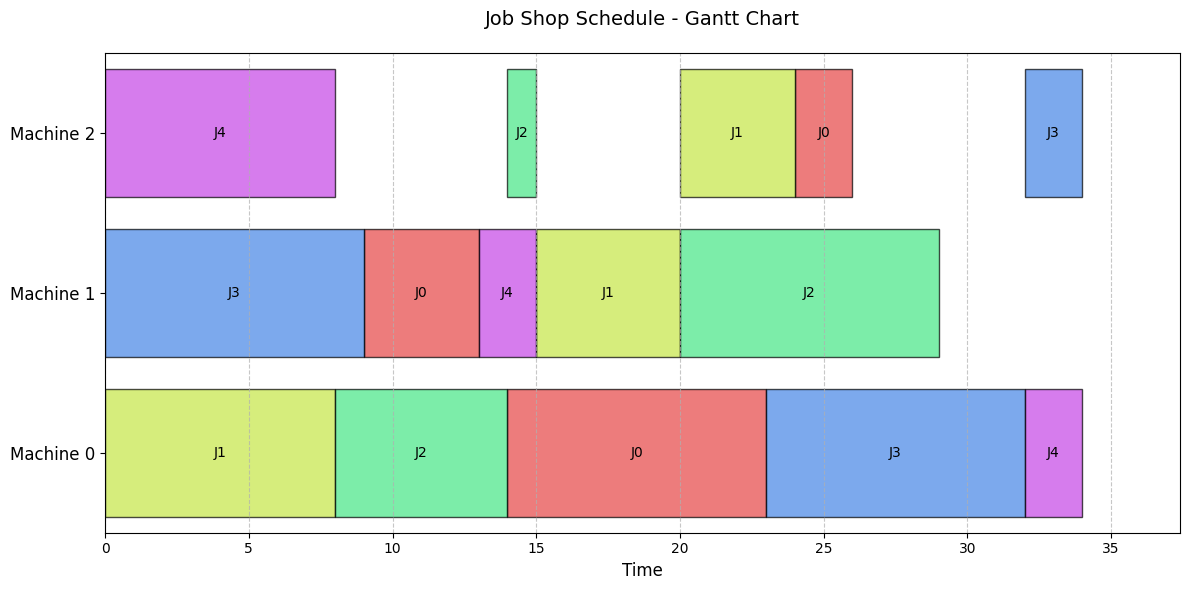

In [7]:
import pulp
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import colorsys
import random

# Function to generate random processing times and machine orders
def generate_random_problem(num_jobs, num_machines):
    machine_order = []
    processing_time = []
    for j in range(num_jobs):
        machines = list(range(num_machines))
        random.shuffle(machines)
        machine_order.append(machines)
        processing_time.append([random.randint(1, 10) for _ in range(num_machines)])
    return machine_order, processing_time

# Get interactive input for number of jobs and machines
while True:
    try:
        num_jobs = int(input("Enter the number of jobs: "))
        num_machines = int(input("Enter the number of machines: "))
        if num_jobs > 0 and num_machines > 0:
            break
        else:
            print("Number of jobs and machines must be positive integers.")
    except ValueError:
        print("Invalid input. Please enter integers.")

# Generate random problem data based on user input
machine_order, processing_time = generate_random_problem(num_jobs, num_machines)

print("\nGenerated Machine Order:")
for j, order in enumerate(machine_order):
    print(f"Job {j}: {order}")

print("\nGenerated Processing Times:")
for j, times in enumerate(processing_time):
    print(f"Job {j}: {times}")


# -------------------------
# 2) DECISION VARIABLES
# -------------------------
# We'll create a variable start_time[m, j] = the start time of Job j on Machine m.
# Because each job visits each machine exactly once (in a known order), we can define variables for each (m, j).
# Alternatively, we might define them only in operation order; for simplicity, we'll define them for (m, j).
start_time = pulp.LpVariable.dicts(
    "start_time",
    [(m, j) for m in range(num_machines) for j in range(num_jobs)],
    lowBound=0,
    cat='Continuous'
)

# We'll create a variable Cmax to represent the makespan (the maximum finishing time).
Cmax = pulp.LpVariable('Cmax', lowBound=0, cat='Continuous')

# -------------------------
# 3) MODEL
# -------------------------
model = pulp.LpProblem("Job_Shop_Scheduling", pulp.LpMinimize)

# Objective: Minimize the makespan
model += Cmax, "Minimize_makespan"

# -------------------------
# 4) CONSTRAINTS
# -------------------------

# (A) **Operation sequence** constraints:
#     For each job j, each operation must start after the previous one finishes.

for j in range(num_jobs):
    for op in range(num_machines - 1):
        current_machine = machine_order[j][op]
        next_machine = machine_order[j][op + 1]

        # Find the processing time for the current operation of job j
        # The index of the current machine in the machine_order for job j gives the operation index
        current_op_idx = machine_order[j].index(current_machine)
        current_op_time = processing_time[j][current_op_idx]


        # The start of the next operation must be >= (start of current operation + processing time).
        model += start_time[next_machine, j] >= (
            start_time[current_machine, j] + current_op_time
        ), f"SequenceConstraint_Job{j}_Op{op}"

# (B) **No overlap on the same machine**:
#     If two jobs j1 and j2 require the same machine m, only one can run at a time.
#     We'll use the "big-M" approach with binary variables to enforce non-overlapping intervals.

# Big M can be a large enough number. A safe upper bound is the sum of all processing times.
bigM = sum(sum(job_times) for job_times in processing_time) + 1

# Create binary variables that indicate ordering between job pairs on each machine.
# y[m, j1, j2] = 1 means job j1 finishes before job j2 starts (on machine m).
y = pulp.LpVariable.dicts(
    "y",
    [(m, j1, j2) for m in range(num_machines) for j1 in range(num_jobs) for j2 in range(num_jobs) if j1 != j2],
    cat='Binary'
)

for m in range(num_machines):
    for j1 in range(num_jobs):
        for j2 in range(num_jobs):
            if j1 != j2:
                # processing time of job j1 on machine m
                # We need to figure out which operation index job j1 uses machine m
                op_j1 = machine_order[j1].index(m)  # index of machine m in job j1's sequence
                proc_j1 = processing_time[j1][op_j1]

                op_j2 = machine_order[j2].index(m)
                proc_j2 = processing_time[j2][op_j2]

                # Non-overlap constraints:
                # start_time[m, j2] >= start_time[m, j1] + proc_j1 - bigM*(1 - y[m, j1, j2])
                model += start_time[m, j2] >= start_time[m, j1] + proc_j1 - bigM * (1 - y[m, j1, j2])

                # Similarly:
                # start_time[m, j1] >= start_time[m, j2] + proc_j2 - bigM*(y[m, j1, j2])
                model += start_time[m, j1] >= start_time[m, j2] + proc_j2 - bigM * (y[m, j1, j2])

# (C) **Makespan definition**:
#     For each job j, the finishing time on its last machine must be <= Cmax.
for j in range(num_jobs):
    # last machine index for job j (the job visits machines in a known order)
    last_machine = machine_order[j][-1]
    # We need to find the processing time for the last operation of job j
    last_op_idx = machine_order[j].index(last_machine)

    finish_time_j = start_time[last_machine, j] + processing_time[j][last_op_idx]

    model += Cmax >= finish_time_j, f"CmaxConstraint_Job{j}"

# -------------------------
# 5) SOLVE
# -------------------------
print("\nSolving the model...")
model.solve(pulp.PULP_CBC_CMD(msg=False))

print("Solution Status:", pulp.LpStatus[model.status])
print("Objective (makespan) =", pulp.value(model.objective))

# Print the start times
print("\n--- Start Times ---")
for (m, j) in start_time:
    print(f"Start time of Job {j} on Machine {m} = {pulp.value(start_time[m, j])}")

# -------------------------
# 6) VISUALIZATION (Gantt Chart)
# -------------------------

# Create Gantt chart
fig_height = max(6, num_machines * 0.7)  # Adjust height based on number of machines
fig, ax = plt.subplots(figsize=(12, fig_height))

# Generate colors dynamically based on number of jobs
def generate_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.7
        value = 0.9
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        colors.append(rgb)
    return colors

colors = generate_colors(num_jobs)

# For each machine and job
for m in range(num_machines):
    for j in range(num_jobs):
        # Get start time and processing time
        start = pulp.value(start_time[m, j])

        # Find the processing time for job j on machine m
        try:
            op_idx = machine_order[j].index(m)
            duration = processing_time[j][op_idx]
        except ValueError:
            # This machine is not in the sequence for this job, skip plotting
            continue


        # Calculate rectangle height based on number of machines
        rect_height = min(0.8, 0.95 - (0.01 * num_machines))

        # Create rectangle for this operation
        rect = patches.Rectangle(
            (start, m - rect_height/2),     # (x,y) - center the rectangle vertically
            duration,                       # width
            rect_height,                    # height
            facecolor=colors[j],
            edgecolor='black',
            alpha=0.7
        )

        # Add rectangle to plot
        ax.add_patch(rect)

        # Adjust text size based on number of jobs and machines
        text_size = max(6, min(10, 150/(num_jobs * num_machines)))

        # Add job number text in the middle of rectangle
        ax.text(start + duration/2, m, f'J{j}', # Center text on the machine line
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=text_size,
                color='white' if max(colors[j]) < 0.5 else 'black' # Choose text color based on background
               )

# Customize the plot
ax.set_ylim(-0.5, num_machines - 0.5)
ax.set_xlim(0, pulp.value(Cmax) * 1.1)  # Add 10% margin

# Adjust tick label size based on number of machines
tick_size = max(8, min(12, 120/num_machines))
ax.set_yticks(range(num_machines))
ax.set_yticklabels([f'Machine {m}' for m in range(num_machines)], fontsize=tick_size)
ax.set_xlabel('Time', fontsize=tick_size)
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.title('Job Shop Schedule - Gantt Chart', pad=20, fontsize=tick_size + 2)
plt.tight_layout()
plt.show()

## Wnioski z zadań harmonogramowania produkcji

### 1. Przykład Mini Problemu (2 zadania, 2 maszyny)

Rozwiązanie dla tego mniejszego problemu dało **optymalny czas zakończenia (makespan) równy 12.0**. Widzimy, że maszyny są efektywnie wykorzystywane, a operacje są planowane tak, aby zminimalizować całkowity czas produkcji.

### 2. Bardziej ogólny przykład (3 zadania, 3 maszyny)

Po zastosowaniu bardziej ogólnej konfiguracji z 3 zadaniami i 3 maszynami, z określonymi sekwencjami maszyn i czasami przetwarzania, optymalny czas zakończenia (makespan) został znaleziony jako **20.0**. Zmiana danych wejściowych w późniejszej komórce (oxjCwapabd59), która zwiększyła liczbę maszyn do 4 i zmodyfikowała czasy przetwarzania, również wykazała **makespan = 20.0**. To pokazuje, jak złożoność problemu i konkretne czasy przetwarzania wpływają na ostateczny harmonogram i makespan.

### 3. Interaktywny przykład (5 zadań, 3 maszyny, losowe dane)

Po interaktywnym wprowadzeniu 5 zadań i 3 maszyn, z losowo wygenerowanymi sekwencjami maszyn i czasami przetwarzania, solver obliczył optymalny czas zakończenia (makespan) równy **34.0**. To zademonstrowało elastyczność modelu w obsłudze zmiennych parametrów problemu i generowaniu harmonogramu nawet dla losowych, potencjalnie trudniejszych konfiguracji.

### Ogólne obserwacje:

*   **Wpływ parametrów na Makespan**: Czas zakończenia (makespan) jest bezpośrednio zależny od liczby zadań, maszyn, sekwencji operacji i czasów przetwarzania. Zwiększenie złożoności problemu (więcej zadań/maszyn) lub dłuższe czasy przetwarzania mają tendencję do zwiększania makespanu.
*   **Algorytm Pulp**: Biblioteka `pulp` skutecznie znajduje optymalne rozwiązanie dla tych problemów, minimalizując makespan. Status `Optimal` wskazuje, że znaleziony harmonogram jest najlepszym możliwym zgodnie z zadanymi ograniczeniami.
*   **Wykres Gantta**: Wykres Gantta jest kluczowym narzędziem wizualizacji harmonogramu, jasno przedstawiając, kiedy każde zadanie jest przetwarzane na każdej maszynie i identyfikując luki lub wąskie gardła.